# 3. Linear regression: how strong is the relationship?

Notebook 2 asked whether price bands can be *predicted* and concluded that, on
this data, they cannot be distinguished from guessing once councils are kept to
one side of the split. This notebook asks the better-posed question: how strong
is the underlying relationship, and is it real?

It does three things:

1. **Reproduces the submitted report's regression tables exactly**, which also
   turns up a discrepancy in how they were built.
2. **Adds what the report was missing** -- R squared, mean absolute error,
   coefficient p-values and confidence intervals, and a mean-predictor baseline.
3. **Separates fit from prediction**, by reporting a held-out estimate alongside
   the in-sample one.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

from vichouse import config, modelling as M, plotting
from vichouse.build_egm import build_egm_by_lga
from vichouse.build_houses import build_houses_by_lga
from vichouse.config import RESULTS, YEARS_MODEL

plotting.apply_style()
RESULTS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(config.MODELLING_DATASET_CSV)
TARGET_COL = "Weighted House Price"
SPECS = [("EGM Rate",), ("Offence Rate",), ("EGM Rate", "Offence Rate")]
print(f"{len(df)} rows, {df['LGA'].nunique()} councils, {df['Year'].nunique()} years")

170 rows, 34 councils, 5 years


## 3.1 Reproducing the submitted report

The report gives three per-year regressions: house price on gambling loss per
head, on offence rate, and on both. All were fitted and scored on the same rows,
so the RMSE and correlation it reports measure *fit*, not prediction.

Reproducing them exactly turned up something the report does not mention. The
gambling-only model was fitted on **170 rows across 34 councils**, while the
offence-only and combined models used **165 rows across 33**. The reason is the
council-rename bug described in the README: the gambling model never touched the
offences table, so it never hit the name mismatch and kept the council the other
two silently lost.

The practical consequence is that the report's headline comparison table set
three models against each other that were not fitted on the same sample.

In [2]:
reference = pd.read_csv(config.REFERENCE / "LinReg.csv")
reference.columns = [c.strip() for c in reference.columns]

# The gambling-only model's sample: houses joined to gambling, with no offences
# table involved and therefore no dropped council.
houses = build_houses_by_lga()
houses["Year"] = houses["Year"].astype(int)
egm_sample = houses.merge(build_egm_by_lga(), on=["LGA", "Year"], how="inner")
egm_sample = egm_sample[egm_sample["Year"].isin(YEARS_MODEL)]

# The other two models' sample: the full three-way join as the original had it,
# i.e. without the council the rename bug dropped.
offence_sample = df[df["LGA"] != "Moreland"]

print(f"gambling-only sample : {len(egm_sample)} rows, {egm_sample['LGA'].nunique()} councils")
print(f"other two samples    : {len(offence_sample)} rows, {offence_sample['LGA'].nunique()} councils")

gambling-only sample : 170 rows, 34 councils
other two samples    : 165 rows, 33 councils


In [3]:
checks = []
for index, columns in enumerate(SPECS):
    block = reference.iloc[index * 5 : (index + 1) * 5].reset_index(drop=True)
    sample = egm_sample if columns == ("EGM Rate",) else offence_sample
    worst_rmse = worst_r = worst_coefficient = 0.0
    for position, (_, yearly) in enumerate(sample.groupby("Year")):
        model = LinearRegression().fit(yearly[list(columns)], yearly[TARGET_COL])
        metrics = M.regression_metrics(
            yearly[TARGET_COL],
            model.predict(yearly[list(columns)]),
            n_features=len(columns),
        )
        worst_rmse = max(worst_rmse, abs(metrics.rmse - block.loc[position, "RMSE"]))
        worst_r = max(worst_r, abs(metrics.pearson_r - block.loc[position, "Pearson Correlation"]))
        worst_coefficient = max(
            worst_coefficient, abs(model.coef_[0] - block.loc[position, "Coefficient 1"])
        )
    checks.append(
        {
            "Model": " + ".join(columns),
            "Rows": len(sample),
            "Max RMSE difference": worst_rmse,
            "Max r difference": worst_r,
            "Max coefficient difference": worst_coefficient,
        }
    )

checks = pd.DataFrame(checks)
checks.to_csv(RESULTS / "regression_reproduction_check.csv", index=False)
checks

,Model,Rows,Max RMSE difference,Max r difference,Max coefficient difference
0,EGM Rate,170,0.000047,0.000034,0.000048
1,Offence Rate,165,0.000050,0.000049,0.000049
2,EGM Rate + Offence Rate,165,0.000015,0.000048,0.000042


All three reproduce to within rounding, which confirms the rebuilt pipeline
produces the same inputs the original analysis used. Regression is
deterministic, so unlike the k-NN results these match exactly rather than
approximately.

## 3.2 The same models, with the metrics the report omitted

Now fitted consistently on all 170 rows, with R squared, MAE, coefficient
significance and a baseline.

The baseline matters most. Always predicting the mean price gives an RMSE equal
to the standard deviation of the target. Any model that does not beat it is
doing nothing.

In [4]:
baseline_rmse = M.regression_baseline_rmse(df[TARGET_COL])
print(f"mean-predictor RMSE (the number to beat): ${baseline_rmse:,.0f}")

rows = []
for columns in SPECS:
    X = df[list(columns)]
    y = df[TARGET_COL]

    in_sample_model = LinearRegression().fit(X, y)
    in_sample = M.regression_metrics(
        y, in_sample_model.predict(X), n_features=len(columns)
    )

    held_out_predictions = M.grouped_regression_predictions(
        LinearRegression(), X, y, df["LGA"]
    )
    held_out = M.regression_metrics(y, held_out_predictions, n_features=len(columns))

    rows.append(
        {
            "Model": " + ".join(columns),
            "In-sample r": in_sample.pearson_r,
            "In-sample R2": in_sample.r2,
            "In-sample RMSE": in_sample.rmse,
            "Held-out R2": held_out.r2,
            "Held-out RMSE": held_out.rmse,
            "Held-out MAE": held_out.mae,
            "RMSE vs baseline": held_out.rmse - baseline_rmse,
        }
    )

summary = pd.DataFrame(rows)
summary.round(4).to_csv(RESULTS / "regression_summary.csv", index=False)
summary.round(4)

mean-predictor RMSE (the number to beat): $491,438


,Model,In-sample r,In-sample R2,In-sample RMSE,Held-out R2,Held-out RMSE,Held-out MAE,RMSE vs baseline
0,EGM Rate,0.4269,0.1823,444399.0788,0.0128,488278.9944,397252.0173,-3158.9078
1,Offence Rate,0.0158,0.0002,491376.6468,-0.1929,536738.9321,423520.7298,45301.0298
2,EGM Rate + Offence Rate,0.4577,0.2095,436947.6236,0.0281,484490.7992,394156.9522,-6947.1030


Three things to read off this table.

**R squared is the honest translation of the correlation.** The report quoted an
average correlation of 0.484 for the combined model, which sounds substantial.
The same fit expressed as R squared is about 0.21 -- roughly four fifths of the
variation in house prices is unexplained.

**The offence rate explains essentially nothing.** Its in-sample R squared is
about 0.0002. The report's 0.02582 was a correlation, which obscured how small
that is.

**Held out, the models barely beat the mean.** Fitted on some councils and
tested on councils it has not seen, the combined model's R squared is close to
zero, and the offence-only model is *worse than predicting the mean* -- a
negative R squared. This is the regression counterpart of notebook 2's result.

## 3.3 Are the coefficients significant?

The report gave coefficients with no standard errors, so there was no way to
tell a real effect from noise at n = 34 per year.

In [5]:
rows = []
for year, yearly in df.groupby("Year"):
    design = sm.add_constant(yearly[["EGM Rate", "Offence Rate"]])
    fitted = sm.OLS(yearly[TARGET_COL], design).fit()
    intervals = fitted.conf_int(alpha=0.05)
    for name in ("EGM Rate", "Offence Rate"):
        rows.append(
            {
                "Year": year,
                "Predictor": name,
                "Coefficient": fitted.params[name],
                "Std error": fitted.bse[name],
                "p-value": fitted.pvalues[name],
                "CI low": intervals.loc[name, 0],
                "CI high": intervals.loc[name, 1],
                "Model R2": fitted.rsquared,
                "Model adj R2": fitted.rsquared_adj,
                "n": int(fitted.nobs),
            }
        )

coefficients = pd.DataFrame(rows)
coefficients.round(4).to_csv(RESULTS / "regression_coefficients.csv", index=False)
coefficients.round(4)

,Year,Predictor,Coefficient,Std error,p-value,CI low,CI high,Model R2,Model adj R2,n
0,2016,EGM Rate,-1435.3272,538.3333,0.0121,-2533.2652,-337.3891,0.1866,0.1341,34
1,2016,Offence Rate,21.8218,21.3701,0.3151,-21.7628,65.4063,0.1866,0.1341,34
2,2017,EGM Rate,-1595.9780,576.9469,0.0095,-2772.6690,-419.2871,0.1982,0.1465,34
3,2017,Offence Rate,26.9249,24.8117,0.2862,-23.6789,77.5288,0.1982,0.1465,34
4,2018,EGM Rate,-1518.1744,507.0391,0.0054,-2552.2874,-484.0614,0.2252,0.1752,34
5,2018,Offence Rate,27.8168,22.8462,0.2326,-18.7784,74.4120,0.2252,0.1752,34
6,2019,EGM Rate,-1522.8862,471.2448,0.0029,-2483.9962,-561.7762,0.2524,0.2041,34
7,2019,Offence Rate,28.0092,22.8855,0.2302,-18.6660,74.6844,0.2524,0.2041,34
8,2020,EGM Rate,-2455.4959,670.0132,0.0009,-3821.9969,-1088.9949,0.3041,0.2592,34
9,2020,Offence Rate,36.1521,23.6139,0.1359,-12.0088,84.3131,0.3041,0.2592,34


In [6]:
significant = coefficients[coefficients["p-value"] < 0.05]
for name in ("EGM Rate", "Offence Rate"):
    hits = significant[significant["Predictor"] == name]
    print(f"{name:14s} significant at p<0.05 in {len(hits)}/5 years")

EGM Rate       significant at p<0.05 in 5/5 years
Offence Rate   significant at p<0.05 in 0/5 years


The gambling coefficient is significant in every year; the offence coefficient
in none. That is the statistical backing the report's qualitative conclusion
needed and did not have.

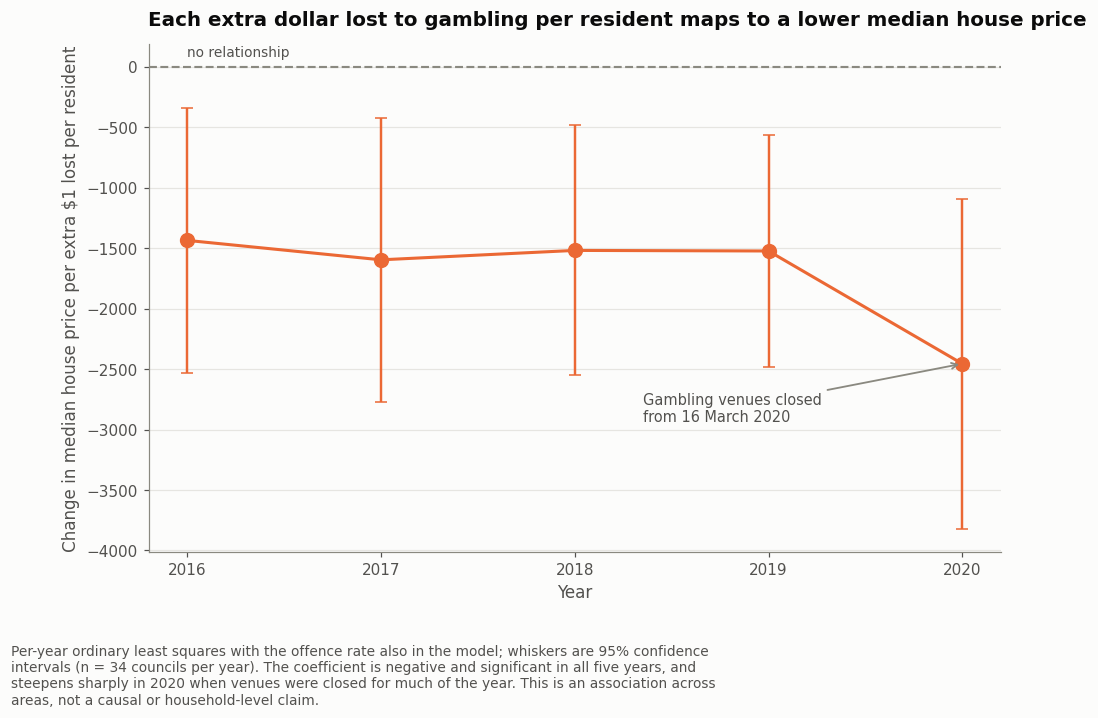

In [7]:
egm_coefficients = coefficients[coefficients["Predictor"] == "EGM Rate"].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(
    egm_coefficients["Year"], egm_coefficients["Coefficient"],
    yerr=[
        egm_coefficients["Coefficient"] - egm_coefficients["CI low"],
        egm_coefficients["CI high"] - egm_coefficients["Coefficient"],
    ],
    fmt="o-", color=plotting.ORANGE, ecolor=plotting.ORANGE,
    elinewidth=1.6, capsize=4, markersize=9, linewidth=2,
)
ax.axhline(0, color=plotting.REFERENCE, linestyle="--", linewidth=1.4)
ax.text(
    2016, 60, "no relationship", color=plotting.INK_SECONDARY, fontsize=9, va="bottom",
)

final = egm_coefficients.iloc[-1]
ax.annotate(
    "Gambling venues closed\nfrom 16 March 2020",
    xy=(2020, final["Coefficient"]),
    xytext=(2018.35, final["Coefficient"] - 480),
    fontsize=9.5, color=plotting.INK_SECONDARY,
    arrowprops=dict(arrowstyle="->", color=plotting.INK_MUTED, linewidth=1.2),
)

ax.set_xticks(list(YEARS_MODEL))
ax.set_xlabel("Year")
ax.set_ylabel("Change in median house price per extra $1 lost per resident")
ax.set_title("Each extra dollar lost to gambling per resident maps to a lower median house price")
plotting.caption(
    fig,
    "Per-year ordinary least squares with the offence rate also in the model; whiskers are 95% "
    "confidence intervals (n = 34 councils per year). The coefficient is negative and "
    "significant in all five years, and steepens sharply in 2020 when venues were closed for "
    "much of the year. This is an association across areas, not a causal or household-level claim.",
)
plotting.save_fig(fig, "12_egm_coefficient_by_year")
plt.show()

In [8]:
first, last = egm_coefficients.iloc[0], egm_coefficients.iloc[-1]
change = (last["Coefficient"] - first["Coefficient"]) / abs(first["Coefficient"]) * 100
overlap = last["CI high"] >= first["CI low"] and first["CI high"] >= last["CI low"]
print(f"2016 coefficient: {first['Coefficient']:9.2f}  95% CI [{first['CI low']:.0f}, {first['CI high']:.0f}]")
print(f"2020 coefficient: {last['Coefficient']:9.2f}  95% CI [{last['CI low']:.0f}, {last['CI high']:.0f}]")
print(f"change: {change:.0f}%")
print(f"\nconfidence intervals overlap: {overlap}")
print(
    "So the steepening is suggestive but not statistically established at n=34."
    if overlap
    else "The intervals are disjoint, so the steepening is unlikely to be noise."
)

2016 coefficient:  -1435.33  95% CI [-2533, -337]
2020 coefficient:  -2455.50  95% CI [-3822, -1089]
change: -71%

confidence intervals overlap: True
So the steepening is suggestive but not statistically established at n=34.


## 3.4 Per-year fits

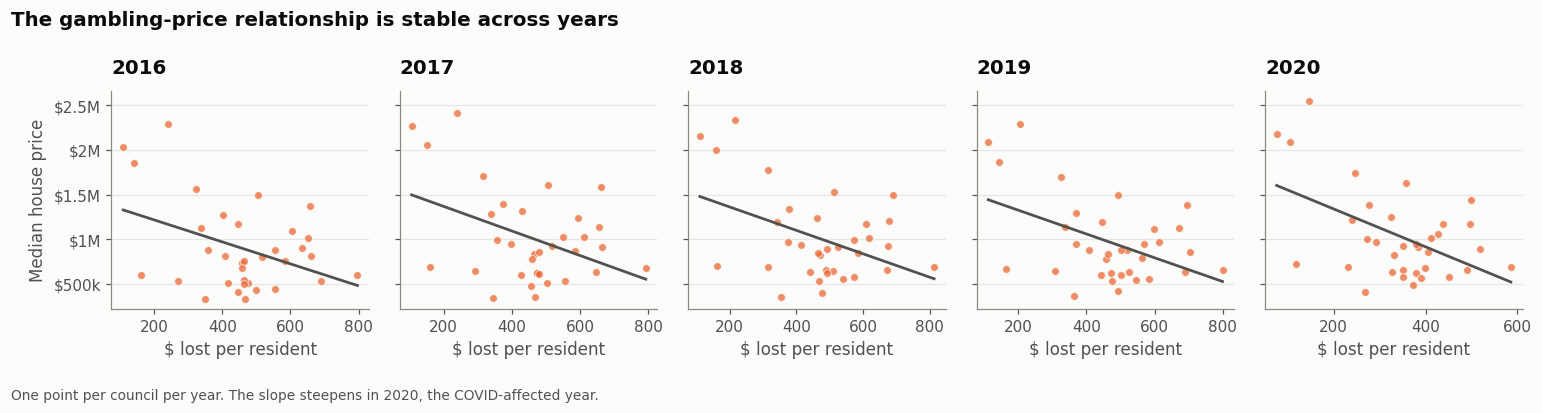

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(14, 3.4), sharey=True)
for ax, (year, yearly) in zip(axes, df.groupby("Year")):
    ax.scatter(
        yearly["EGM Rate"], yearly[TARGET_COL],
        s=26, color=plotting.ORANGE, alpha=0.75,
        edgecolor=plotting.SURFACE, linewidth=0.6,
    )
    model = LinearRegression().fit(yearly[["EGM Rate"]], yearly[TARGET_COL])
    grid = pd.DataFrame(
        {"EGM Rate": np.linspace(yearly["EGM Rate"].min(), yearly["EGM Rate"].max(), 50)}
    )
    ax.plot(grid["EGM Rate"], model.predict(grid), color=plotting.INK_SECONDARY, linewidth=1.8)
    ax.set_title(str(year))
    ax.set_xlabel("$ lost per resident")
axes[0].set_ylabel("Median house price")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(plotting.thousands))
fig.suptitle(
    "The gambling-price relationship is stable across years",
    x=0.0, ha="left", fontsize=13, fontweight="semibold", color=plotting.INK,
)
plotting.caption(
    fig,
    "One point per council per year. The slope steepens in 2020, the COVID-affected year.",
)
fig.tight_layout()
plotting.save_fig(fig, "11_regression_fits_by_year")
plt.show()

## 3.5 The City of Melbourne outlier, diagnosed rather than assumed

One of the original notebooks refits every model with the City of Melbourne
removed, on the reasoning that its offence rate per *resident* is inflated by a
daytime population of commuters who are not counted in the denominator. That
reasoning is sound, but no diagnostic was run to support it.

Cook's distance measures how much the fit would move if a point were dropped.

In [10]:
pooled = sm.add_constant(df[["EGM Rate", "Offence Rate"]])
fit = sm.OLS(df[TARGET_COL], pooled).fit()
influence = fit.get_influence()
df_influence = df.assign(
    cooks=influence.cooks_distance[0], leverage=influence.hat_matrix_diag
)
threshold = 4 / len(df)

top = df_influence.nlargest(6, "cooks")[["LGA", "Year", "Offence Rate", "cooks", "leverage"]]
print(f"Cook's distance threshold (4/n): {threshold:.4f}\n")
print(top.round(4).to_string(index=False))

Cook's distance threshold (4/n): 0.0235

        LGA  Year  Offence Rate  cooks  leverage
  Melbourne  2017      23392.50 0.0789    0.1122
Stonnington  2020      10290.38 0.0747    0.0356
  Melbourne  2018      22141.49 0.0608    0.0961
 Boroondara  2017       4094.04 0.0474    0.0333
  Melbourne  2019      21512.62 0.0401    0.0886
Stonnington  2017       8811.78 0.0389    0.0178


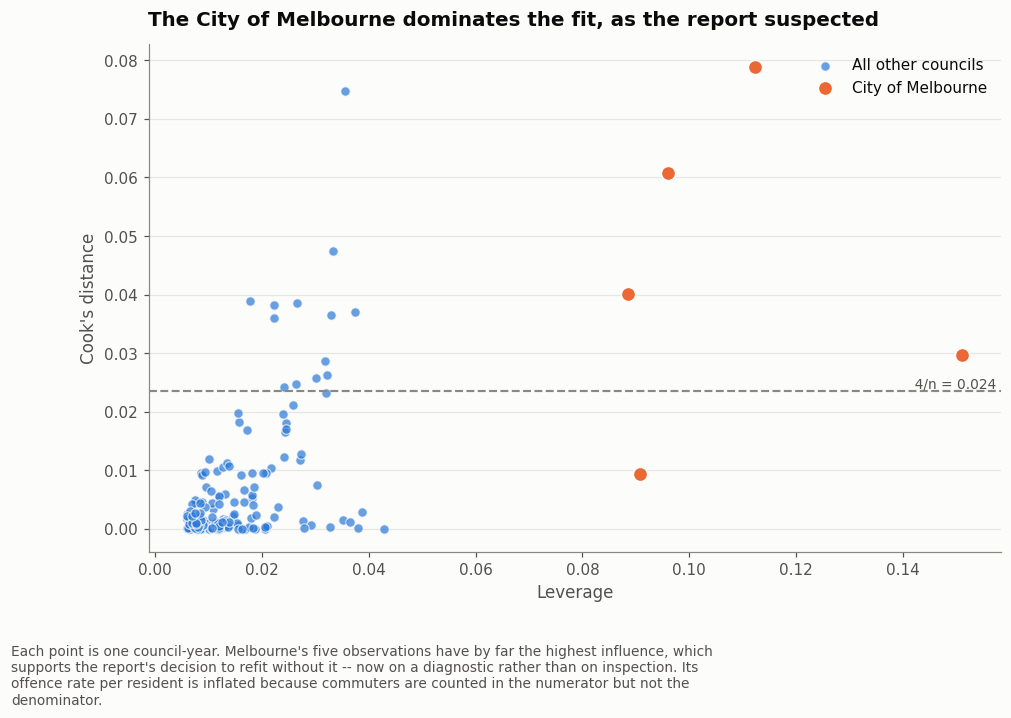

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
melbourne = df_influence["LGA"] == "Melbourne"
ax.scatter(
    df_influence.loc[~melbourne, "leverage"], df_influence.loc[~melbourne, "cooks"],
    s=38, color=plotting.BLUE, alpha=0.7, edgecolor=plotting.SURFACE, linewidth=0.8,
    label="All other councils",
)
ax.scatter(
    df_influence.loc[melbourne, "leverage"], df_influence.loc[melbourne, "cooks"],
    s=90, color=plotting.ORANGE, edgecolor=plotting.SURFACE, linewidth=1.2,
    label="City of Melbourne", zorder=3,
)
ax.axhline(threshold, color=plotting.REFERENCE, linestyle="--", linewidth=1.4)
ax.text(
    ax.get_xlim()[1], threshold, f"  4/n = {threshold:.3f} ",
    ha="right", va="bottom", fontsize=9, color=plotting.INK_SECONDARY,
)
ax.set_xlabel("Leverage")
ax.set_ylabel("Cook's distance")
ax.set_title("The City of Melbourne dominates the fit, as the report suspected")
ax.legend()
plotting.caption(
    fig,
    "Each point is one council-year. Melbourne's five observations have by far the highest "
    "influence, which supports the report's decision to refit without it -- now on a diagnostic "
    "rather than on inspection. Its offence rate per resident is inflated because commuters are "
    "counted in the numerator but not the denominator.",
)
plotting.save_fig(fig, "13_influence_diagnostics")
plt.show()

In [12]:
without_melbourne = df[df["LGA"] != "Melbourne"]
rows = []
for label, sample in [("All councils", df), ("Excluding Melbourne", without_melbourne)]:
    for columns in SPECS:
        model = LinearRegression().fit(sample[list(columns)], sample[TARGET_COL])
        metrics = M.regression_metrics(
            sample[TARGET_COL],
            model.predict(sample[list(columns)]),
            n_features=len(columns),
        )
        rows.append(
            {
                "Sample": label,
                "Model": " + ".join(columns),
                "Offence coefficient": (
                    model.coef_[list(columns).index("Offence Rate")]
                    if "Offence Rate" in columns else np.nan
                ),
                "r": metrics.pearson_r,
                "R2": metrics.r2,
                "RMSE": metrics.rmse,
            }
        )

outliers = pd.DataFrame(rows)
outliers.round(4).to_csv(RESULTS / "regression_outlier_sensitivity.csv", index=False)
outliers.round(4)

,Sample,Model,Offence coefficient,r,R2,RMSE
0,All councils,EGM Rate,NaN,0.4269,0.1823,444399.0788
1,All councils,Offence Rate,2.1663,0.0158,0.0002,491376.6468
2,All councils,EGM Rate + Offence Rate,23.9505,0.4577,0.2095,436947.6236
3,Excluding Melbourne,EGM Rate,NaN,0.4841,0.2343,430249.5043
4,Excluding Melbourne,Offence Rate,-29.2416,0.1501,0.0225,486129.1684
5,Excluding Melbourne,EGM Rate + Offence Rate,-6.1236,0.4850,0.2353,429988.9191


Removing Melbourne flips the sign of the offence coefficient, which the original
noticed but read as unimportant. It is actually the more interesting reading:
the weak positive crime-price association in the full sample is produced
entirely by the central business district, where a high recorded offence rate
coincides with high prices for reasons that have nothing to do with the
relationship being tested. Outside the CBD the association is, if anything,
mildly negative.

## 3.6 What this notebook established

* The report's three regressions reproduce exactly, and were fitted on two
  different samples -- the gambling model on 34 councils, the other two on 33.
* Expressed as R squared rather than correlation, the combined model explains
  about a fifth of the variation in house prices in-sample, and essentially none
  of it on held-out councils.
* The gambling coefficient is negative and significant in all five years; the
  offence coefficient is significant in none.
* The gambling coefficient steepens markedly in 2020, the year gambling venues
  were closed from 16 March.
* The apparent crime-price association in the full sample is an artefact of the
  City of Melbourne.

The defensible conclusion is descriptive, not predictive: **areas where more is
lost per resident on poker machines have lower median house prices**, a
consistent and statistically clear association across all five years, which does
not generalise well enough to predict an unseen council's price band. Recorded
crime shows no such relationship.

Causality is not established in either direction. Household income is an obvious
common cause of both, and nothing here can separate that from the alternatives.